# ALFRED Environment Exploration

**Goal:** Understand the ALFRED benchmark (Action Learning From Realistic Environments and Directives) — dataset structure, language annotations, action space, and AI2-THOR integration — before using it for the 3D-VLA thesis pipeline.

**Paper:** *ALFRED: A Benchmark for Interpreting Grounded Instructions for Everyday Tasks* — Shridhar et al. (CVPR 2020)  
**Environment:** AI2-THOR (The House Of inteRactions)  
**Kernel:** uv-managed Python 3.12 env (`uv run jupyter lab`)

---
## Table of Contents
1. [Setup & Imports](#1)
2. [Dataset Overview](#2)
3. [Trajectory Deep-Dive](#3)
4. [Language Annotations](#4)
5. [Action Sequence Analysis](#5)
6. [AI2-THOR Environment](#6)
7. [Scene Navigation](#7)
8. [Object Interaction](#8)
9. [Thesis Notes](#9)

---
## 1. Setup & Imports <a id='1'></a>

In [1]:
import sys, os, json
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path(os.path.abspath(".."))
sys.path.insert(0, str(REPO_ROOT / "src"))

from alfred_env import AlfredAction, TASK_TYPES, SCREEN_WIDTH, SCREEN_HEIGHT
from alfred_env.data_utils import DATA_ROOT, load_trajectory, iter_dataset, get_dataset_stats

print(f"DATA_ROOT: {DATA_ROOT}")
print(f"Data exists: {DATA_ROOT.exists()}")
print(f"Actions: {[a.name for a in AlfredAction]}")
print(f"Task types: {len(TASK_TYPES)}")

DATA_ROOT: /Users/lucamac/Coding/Master-Thesis-3D-VLA/.claude/worktrees/jolly-sniffing-pascal/data/alfred/json_2.1.0
Data exists: True
Actions: ['MoveAhead', 'RotateRight', 'RotateLeft', 'LookUp', 'LookDown', 'PickupObject', 'PutObject', 'OpenObject', 'CloseObject', 'ToggleObjectOn', 'ToggleObjectOff', 'SliceObject']
Task types: 7


---
## 2. Dataset Overview <a id='2'></a>

ALFRED contains ~25k expert demonstrations across 7 task types in 120 AI2-THOR kitchens/living rooms/bedrooms/bathrooms.

In [2]:
# Split sizes
split_sizes = {}
for split in ["train", "valid_seen", "valid_unseen"]:
    split_dir = DATA_ROOT / split
    if not split_dir.exists():
        print(f"  {split}: NOT DOWNLOADED")
        continue
    n = sum(1 for _ in iter_dataset(split))
    split_sizes[split] = n
    print(f"  {split}: {n} trajectories")

print(f"\nTotal: {sum(split_sizes.values())} trajectories")

  train: 6574 trajectories
  valid_seen: 251 trajectories
  valid_unseen: 255 trajectories

Total: 7080 trajectories


Train: 6574 trajs, 108 scenes
Avg low actions: 49.8, avg instructions: 6.7


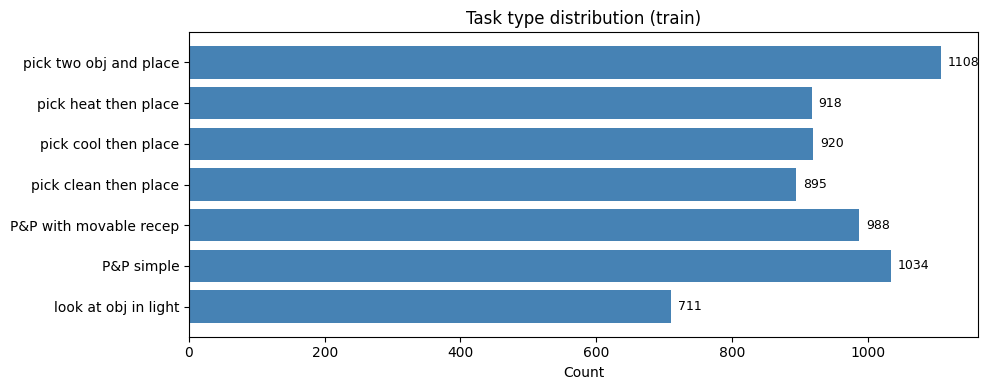

In [3]:
# Task type distribution (train split)
stats = get_dataset_stats("train")
print(f"Train: {stats.num_trajectories} trajs, {len(stats.unique_scenes)} scenes")
print(f"Avg low actions: {stats.avg_low_actions:.1f}, avg instructions: {stats.avg_instructions:.1f}")

# Bar chart
types = sorted(stats.task_type_counts.keys())
counts = [stats.task_type_counts[t] for t in types]
short_names = [t.replace("_", " ").replace(" in recep", "").replace("pick and place", "P&P") for t in types]

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(short_names, counts, color="steelblue")
ax.set_xlabel("Count")
ax.set_title("Task type distribution (train)")
for i, c in enumerate(counts):
    ax.text(c + 10, i, str(c), va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [4]:
# Unique scenes
print(f"Unique scenes in train: {len(stats.unique_scenes)}")
print(f"Sample scenes: {sorted(stats.unique_scenes)[:10]}")

Unique scenes in train: 108
Sample scenes: [1, 2, 3, 4, 5, 6, 7, 8, 11, 12]


---
## 3. Trajectory Deep-Dive <a id='3'></a>

Each trajectory has:
- `task_type`: one of 7 types
- `turk_annotations`: 3 annotators each providing goal + step-by-step instructions
- `plan.high_pddl`: PDDL high-level action plan
- `plan.low_actions`: low-level API calls with discrete actions + object masks

In [5]:
# Load first trajectory
traj = next(iter_dataset("train"))

print(f"Task ID:   {traj.task_id}")
print(f"Task type: {traj.task_type}")
print(f"Scene:     {traj.scene}")
print(f"Goal:      {traj.goal}")
print(f"\nStep-by-step instructions ({len(traj.instructions)}):\n")
for i, inst in enumerate(traj.instructions):
    print(f"  {i+1}. {inst}")

Task ID:   trial_T20190907_174127_043461
Task type: look_at_obj_in_light
Scene:     301
Goal:      Pick up the alarm clock and turn on the lamp.

Step-by-step instructions (4):

  1. Turn left and face the dresser.
  2. Pick up the alarm clock from the dresser.
  3. Turn left, look and then face the lamp.
  4. Turn the lamp on.


In [6]:
# High-level plan (PDDL)
print(f"High-level plan ({len(traj.plan)} steps):\n")
for i, step in enumerate(traj.plan):
    planner_action = step.get("planner_action", step.get("discrete_action", {}))
    print(f"  {i}. {planner_action.get('action', '?')} -> {planner_action.get('coordinateObjectId', ['?'])[:1]}")

High-level plan (5 steps):

  0. GotoLocation -> ['?']
  1. PickupObject -> ['AlarmClock']
  2. GotoLocation -> ['?']
  3. ToggleObject -> ['DeskLamp']
  4. End -> ['?']


In [7]:
# Low-level actions breakdown
action_names = [a["api_action"]["action"] for a in traj.low_actions]
print(f"Low-level actions ({len(action_names)} total):\n")
for name, count in Counter(action_names).most_common():
    print(f"  {name:<25} {count:>3}")

print(f"\nFirst 10 actions: {action_names[:10]}")

Low-level actions (12 total):

  MoveAhead                   3
  LookDown                    2
  RotateLeft                  2
  LookUp                      2
  PickupObject                1
  RotateRight                 1
  ToggleObjectOn              1

First 10 actions: ['LookDown', 'MoveAhead', 'MoveAhead', 'RotateLeft', 'LookUp', 'PickupObject', 'LookDown', 'RotateLeft', 'MoveAhead', 'RotateRight']


---
## 4. Language Annotations <a id='4'></a>

Each trajectory has 3 independent annotators. Each provides a task description + step instructions.

In [8]:
# Show all annotator variants
print(f"Number of annotators: {len(traj.turk_annotations)}\n")
for ann_idx, ann in enumerate(traj.turk_annotations):
    print(f"--- Annotator {ann_idx} ---")
    print(f"  Goal: {ann['task_desc']}")
    print(f"  Steps ({len(ann['high_descs'])}):\n")
    for i, desc in enumerate(ann["high_descs"]):
        print(f"    {i+1}. {desc}")
    print()

Number of annotators: 3

--- Annotator 0 ---
  Goal: Pick up the alarm clock and turn on the lamp.
  Steps (4):

    1. Turn left and face the dresser.
    2. Pick up the alarm clock from the dresser.
    3. Turn left, look and then face the lamp.
    4. Turn the lamp on.

--- Annotator 1 ---
  Goal: Carry an alarm clock while turning on a lamp
  Steps (4):

    1. Move to the white dresser to the left of the bed
    2. Pick up the alarm clock on top of the dresser
    3. Carry the alarm clock to the left side of the dresser
    4. Turn on the lamp on top of the dresser

--- Annotator 2 ---
  Goal: examine an alarm clock by the light of the lamp on the dresser
  Steps (4):

    1. turn to the left to face the dresser
    2. pick up the alarm clock off of the dresser
    3. move to the left to face the left side of the dresser where the lamp is sitting
    4. turn the lamp on



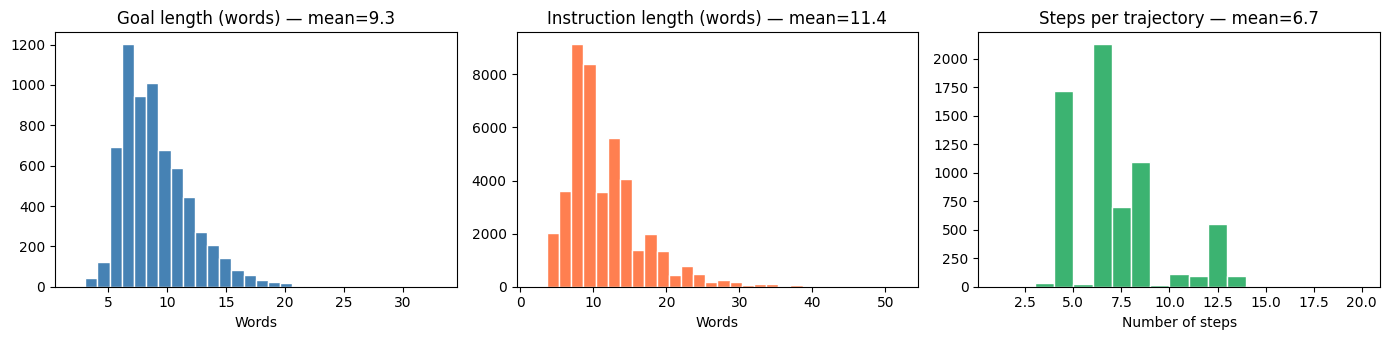

In [9]:
# Instruction length analysis across train set
goal_lengths = []
instr_lengths = []
num_steps = []

for i, traj in enumerate(iter_dataset("train")):
    goal_lengths.append(len(traj.goal.split()))
    for inst in traj.instructions:
        instr_lengths.append(len(inst.split()))
    num_steps.append(len(traj.instructions))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

axes[0].hist(goal_lengths, bins=30, color="steelblue", edgecolor="white")
axes[0].set_title(f"Goal length (words) — mean={np.mean(goal_lengths):.1f}")
axes[0].set_xlabel("Words")

axes[1].hist(instr_lengths, bins=30, color="coral", edgecolor="white")
axes[1].set_title(f"Instruction length (words) — mean={np.mean(instr_lengths):.1f}")
axes[1].set_xlabel("Words")

axes[2].hist(num_steps, bins=range(1, max(num_steps)+2), color="mediumseagreen", edgecolor="white")
axes[2].set_title(f"Steps per trajectory — mean={np.mean(num_steps):.1f}")
axes[2].set_xlabel("Number of steps")

plt.tight_layout()
plt.show()

---
## 5. Action Sequence Analysis <a id='5'></a>

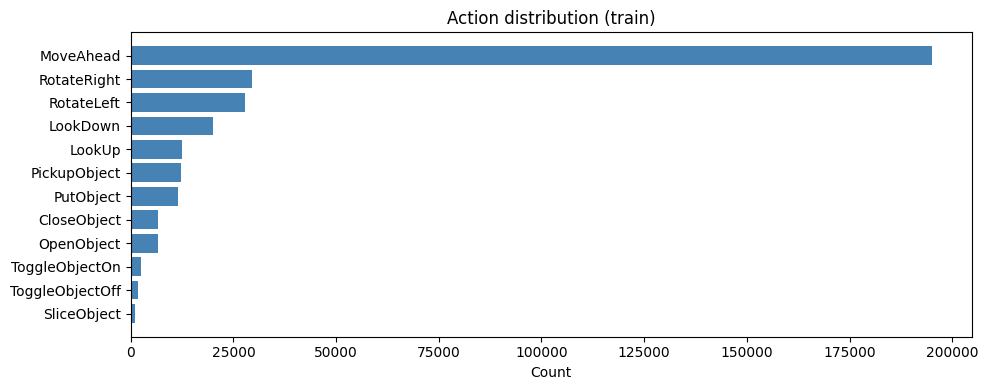


Total actions: 327,270
Unique action types: 12


In [10]:
# Action distribution across entire train set
all_actions = Counter()
traj_lengths = []
traj_lengths_by_type = {}

for traj in iter_dataset("train"):
    actions = [a["api_action"]["action"] for a in traj.low_actions]
    all_actions.update(actions)
    traj_lengths.append(len(actions))
    traj_lengths_by_type.setdefault(traj.task_type, []).append(len(actions))

# Action distribution bar chart
action_names, action_counts = zip(*all_actions.most_common())
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(action_names[::-1], action_counts[::-1], color="steelblue")
ax.set_xlabel("Count")
ax.set_title("Action distribution (train)")
plt.tight_layout()
plt.show()

print(f"\nTotal actions: {sum(action_counts):,}")
print(f"Unique action types: {len(action_names)}")

/var/folders/q9/hh7snjjx2ys334gt9qzrp4pc0000gn/T/ipykernel_16562/581932013.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, labels=short, patch_artist=True)


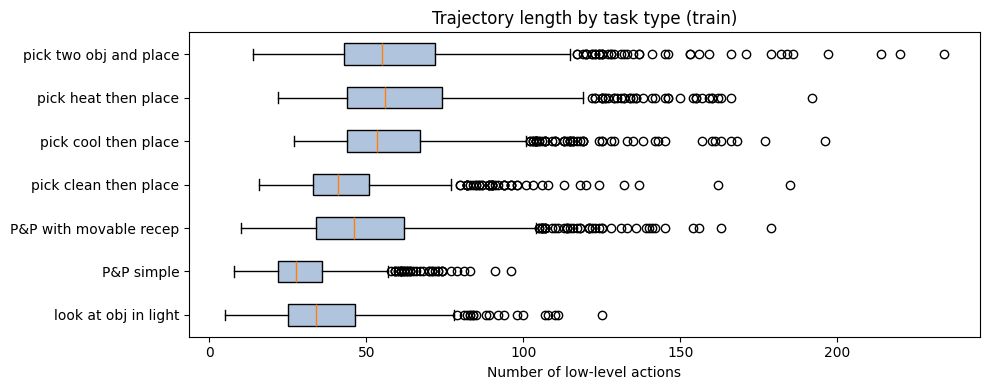


Overall: mean=50, median=45, max=234


In [11]:
# Trajectory lengths per task type — box plot
types_sorted = sorted(traj_lengths_by_type.keys())
data = [traj_lengths_by_type[t] for t in types_sorted]
short = [t.replace("_", " ").replace(" in recep", "").replace("pick and place", "P&P") for t in types_sorted]

fig, ax = plt.subplots(figsize=(10, 4))
bp = ax.boxplot(data, vert=False, labels=short, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("lightsteelblue")
ax.set_xlabel("Number of low-level actions")
ax.set_title("Trajectory length by task type (train)")
plt.tight_layout()
plt.show()

print(f"\nOverall: mean={np.mean(traj_lengths):.0f}, median={np.median(traj_lengths):.0f}, max={max(traj_lengths)}")

---
## 6. AI2-THOR Environment <a id='6'></a>

Launch AI2-THOR controller and render a frame. Requires a display (macOS GUI window).

**Note:** ai2thor >= 5.0 uses Unity; scenes are downloaded on first use.

/Users/lucamac/Coding/Master-Thesis-3D-VLA/.venv/lib/python3.12/site-packages/ai2thor/controller.py:1147: SyntaxWarning: invalid escape sequence '\ '
  "~/.config/unity3d/Allen\ Institute\ for\ "
/Users/lucamac/Coding/Master-Thesis-3D-VLA/.venv/lib/python3.12/site-packages/ai2thor/controller.py:1148: SyntaxWarning: invalid escape sequence '\ '
  "Artificial\ Intelligence/AI2-THOR/Player.log for errors. "
/Users/lucamac/Coding/Master-Thesis-3D-VLA/.venv/lib/python3.12/site-packages/ai2thor/fifo_server.py:155: SyntaxWarning: invalid escape sequence '\ '
  "~/.config/unity3d/Allen\ Institute\ for\ "
/Users/lucamac/Coding/Master-Thesis-3D-VLA/.venv/lib/python3.12/site-packages/ai2thor/fifo_server.py:156: SyntaxWarning: invalid escape sequence '\ '
  "Artificial\ Intelligence/AI2-THOR/Player.log for errors. "


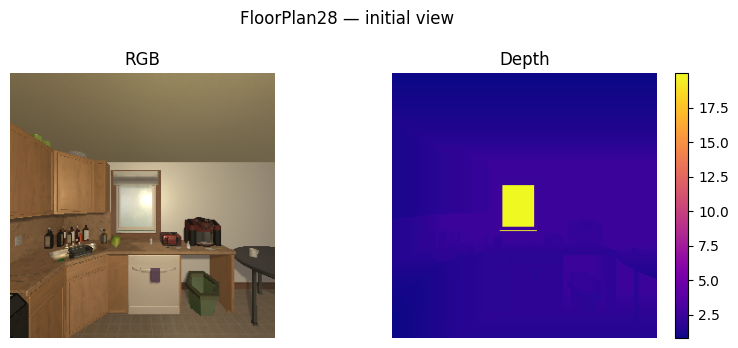

Frame: (300, 300, 3) uint8
Depth: (300, 300) range=[0.82, 19.99]


In [12]:
from ai2thor.controller import Controller

controller = Controller(
    scene="FloorPlan28",
    gridSize=0.25,
    width=SCREEN_WIDTH,
    height=SCREEN_HEIGHT,
    renderDepthImage=True,
)
event = controller.step(action="Pass")

frame = event.frame  # [H, W, 3] uint8
depth = event.depth_frame  # [H, W] float

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))
ax1.imshow(frame)
ax1.set_title("RGB")
ax1.axis("off")
im = ax2.imshow(depth, cmap="plasma")
ax2.set_title("Depth")
ax2.axis("off")
plt.colorbar(im, ax=ax2, fraction=0.046)
plt.suptitle("FloorPlan28 — initial view")
plt.tight_layout()
plt.show()

print(f"Frame: {frame.shape} {frame.dtype}")
print(f"Depth: {depth.shape} range=[{depth.min():.2f}, {depth.max():.2f}]")

---
## 7. Scene Navigation <a id='7'></a>

Execute a sequence of navigation actions and display a frame grid.

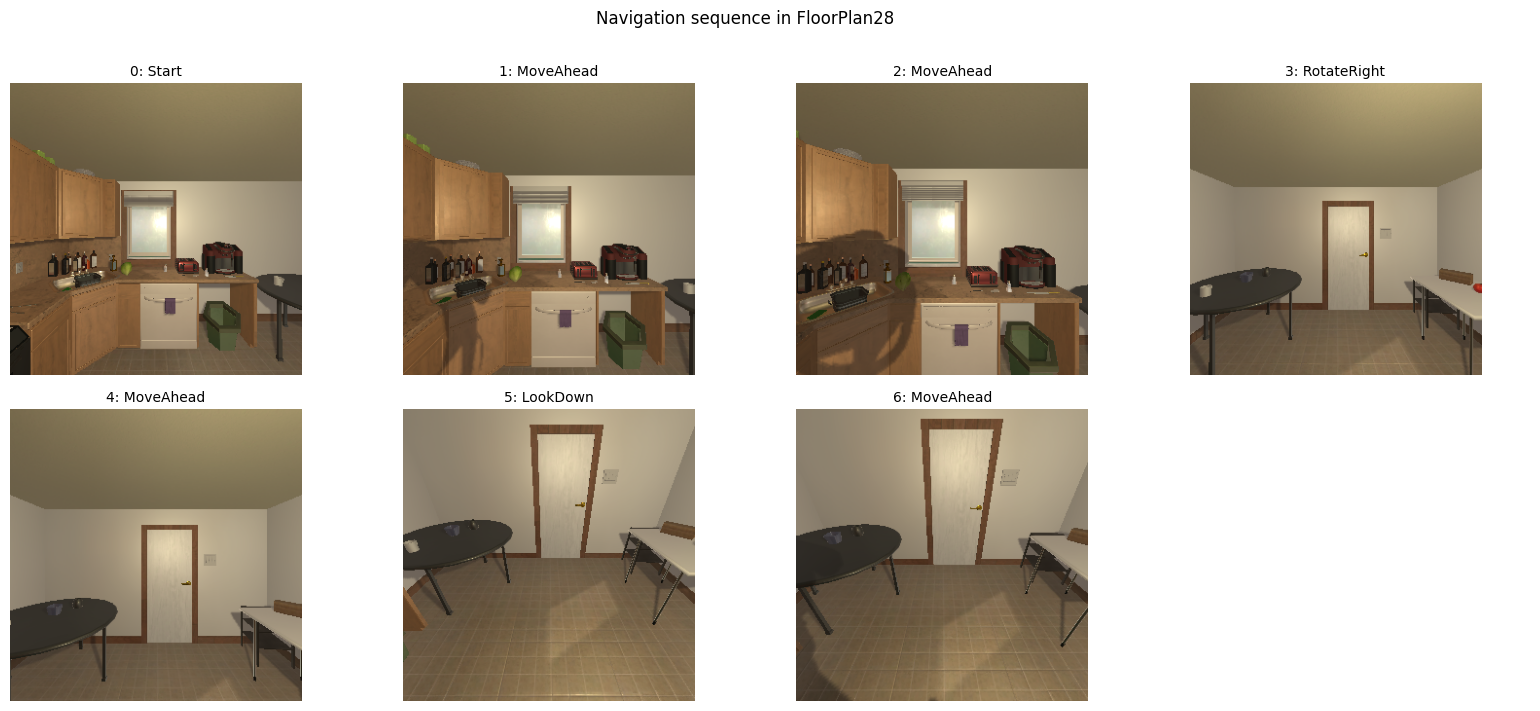

In [13]:
# Navigation sequence: move + rotate + look
nav_actions = [
    ("MoveAhead", {}),
    ("MoveAhead", {}),
    ("RotateRight", {}),
    ("MoveAhead", {}),
    ("LookDown", {}),
    ("MoveAhead", {}),
]

frames = []
labels = []

# Reset
controller.reset(scene="FloorPlan28")
event = controller.step(action="Pass")
frames.append(event.frame)
labels.append("Start")

for action, kwargs in nav_actions:
    event = controller.step(action=action, **kwargs)
    frames.append(event.frame)
    labels.append(action)

# Display grid
n = len(frames)
cols = min(n, 4)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows))
axes = np.array(axes).flatten()
for i, (frame, label) in enumerate(zip(frames, labels)):
    axes[i].imshow(frame)
    axes[i].set_title(f"{i}: {label}", fontsize=10)
    axes[i].axis("off")
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
plt.suptitle("Navigation sequence in FloorPlan28", y=1.01)
plt.tight_layout()
plt.show()

---
## 8. Object Interaction <a id='8'></a>

Demo PickupObject, PutObject, OpenObject. Uses object IDs from metadata.

In [14]:
# Reset and list visible/interactable objects
controller.reset(scene="FloorPlan28")
event = controller.step(action="Pass")

visible = [obj for obj in event.metadata["objects"] if obj["visible"]]
print(f"Visible objects ({len(visible)}):\n")
for obj in visible[:15]:
    flags = []
    if obj["pickupable"]: flags.append("pickup")
    if obj["openable"]: flags.append("open")
    if obj["toggleable"]: flags.append("toggle")
    print(f"  {obj['objectId']:<45} [{', '.join(flags)}]")

Visible objects (4):

  Cabinet|-00.63|+00.39|-02.51                  [open]
  CounterTop|-01.94|+00.98|-03.67               []
  Drawer|-00.48|+00.78|-02.74                   [open]
  Floor|+00.00|+00.00|+00.00                    []


In [15]:
# Try to pick up a visible pickupable object
pickupable = [obj for obj in visible if obj["pickupable"]]
if pickupable:
    target = pickupable[0]
    print(f"Attempting to pick up: {target['objectId']}")
    event = controller.step(action="PickupObject", objectId=target["objectId"], forceAction=True)
    print(f"Success: {event.metadata['lastActionSuccess']}")
    if not event.metadata["lastActionSuccess"]:
        print(f"Error: {event.metadata['errorMessage']}")
    
    fig, ax = plt.subplots(figsize=(4, 3.5))
    ax.imshow(event.frame)
    ax.set_title(f"After PickupObject({target['objectType']})")
    ax.axis("off")
    plt.show()
    
    # Put it back down
    receptacles = [obj for obj in event.metadata["objects"] if obj["receptacle"] and obj["visible"]]
    if receptacles:
        recep = receptacles[0]
        print(f"\nPutting on: {recep['objectId']}")
        event = controller.step(action="PutObject", objectId=recep["objectId"], forceAction=True)
        print(f"Success: {event.metadata['lastActionSuccess']}")
else:
    print("No pickupable objects visible — try navigating first.")

No pickupable objects visible — try navigating first.


Opening: Cabinet|-00.63|+00.39|-02.51
Success: True


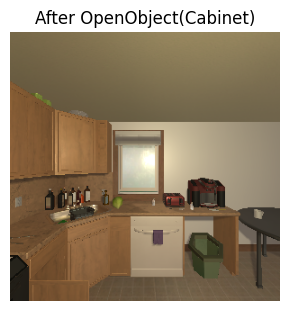

In [16]:
# Open an openable object
openable = [obj for obj in visible if obj["openable"] and not obj["isOpen"]]
if openable:
    target = openable[0]
    print(f"Opening: {target['objectId']}")
    event = controller.step(action="OpenObject", objectId=target["objectId"], forceAction=True)
    print(f"Success: {event.metadata['lastActionSuccess']}")
    
    fig, ax = plt.subplots(figsize=(4, 3.5))
    ax.imshow(event.frame)
    ax.set_title(f"After OpenObject({target['objectType']})")
    ax.axis("off")
    plt.show()
else:
    print("No openable objects visible.")

In [17]:
controller.stop()
print("Controller stopped.")

Controller stopped.


---
## 9. Thesis Notes <a id='9'></a>

### ALFRED → 3D-VLA Relevance

| Aspect | ALFRED | Thesis (3D-VLA) |
|--------|--------|------------------|
| **Environment** | AI2-THOR (indoor sim) | HM3D (photorealistic) |
| **Task** | 7 household task types | ObjectNav |
| **Actions** | 12 discrete (nav + interact) | Continuous / discrete nav |
| **Language** | Goal + step instructions | Goal only |
| **3D** | RGB-D from simulator | UNITE dense 3D features |
| **Model** | Seq2Seq / ET / FILM | OpenVLA + UNITE features |

### Key Takeaways

- ALFRED's **action space** (12 discrete actions) is a natural fit for VLA token prediction
- **Language grounding**: step instructions decompose high-level goals — relevant for instruction-conditioned VLA
- **AI2-THOR** provides ground-truth depth, segmentation, object state — useful for UNITE feature validation
- Gymnasium wrapper deferred: will create `AlfredGymEnv` wrapping the controller for RL training

### Next Steps

- [ ] Create Gymnasium wrapper (`thor_wrapper.py`)
- [ ] Extract UNITE-compatible features from AI2-THOR depth + segmentation
- [ ] Compare ALFRED action space with HM3D ObjectNav actions
- [ ] Run baseline Seq2Seq model on ALFRED for comparison